In [1]:
%pip install sklearn

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


In [2]:

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
#Chargement des données
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
#Affichage des premières lignes
print("Aperçu des données:")
print(df.head())
print("\nInformations sur le dataset:")
print(df.info())

Aperçu des données:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   Av

In [3]:
df.shape

(20640, 9)

In [4]:
df.columns


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [5]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [ ]:
print("Moyenne du prix des maisons:"   ,   df["MedHouseVal"].mean().round(4))

Moyenne du prix des maisons: 2.0686


In [ ]:
print("Âge moyen des maisons :",   df["HouseAge"].mean().round(2))

Âge moyen des maisons : 28.64


In [12]:
df.min().round(4)


MedInc           0.4999
HouseAge         1.0000
AveRooms         0.8462
AveBedrms        0.3333
Population       3.0000
AveOccup         0.6923
Latitude        32.5400
Longitude     -124.3500
MedHouseVal      0.1500
dtype: float64

In [13]:
df.max().round(4)


MedInc            15.0001
HouseAge          52.0000
AveRooms         141.9091
AveBedrms         34.0667
Population     35682.0000
AveOccup        1243.3333
Latitude          41.9500
Longitude       -114.3100
MedHouseVal        5.0000
dtype: float64

In [14]:
df.std().round(4)

MedInc            1.8998
HouseAge         12.5856
AveRooms          2.4742
AveBedrms         0.4739
Population     1132.4621
AveOccup         10.3860
Latitude          2.1360
Longitude         2.0035
MedHouseVal       1.1540
dtype: float64

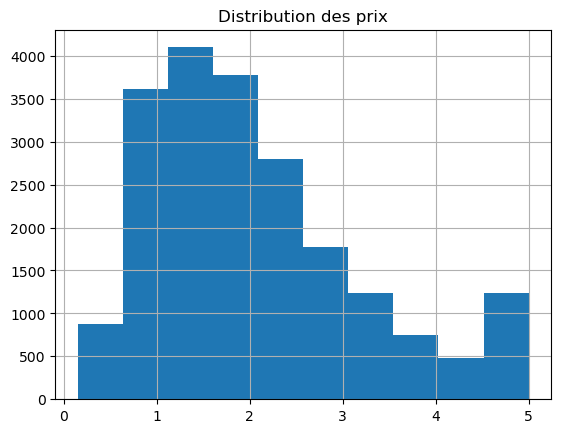

In [17]:
import matplotlib.pyplot as plt

df["MedHouseVal"].hist()
plt.title("Distribution des prix")
plt.show()

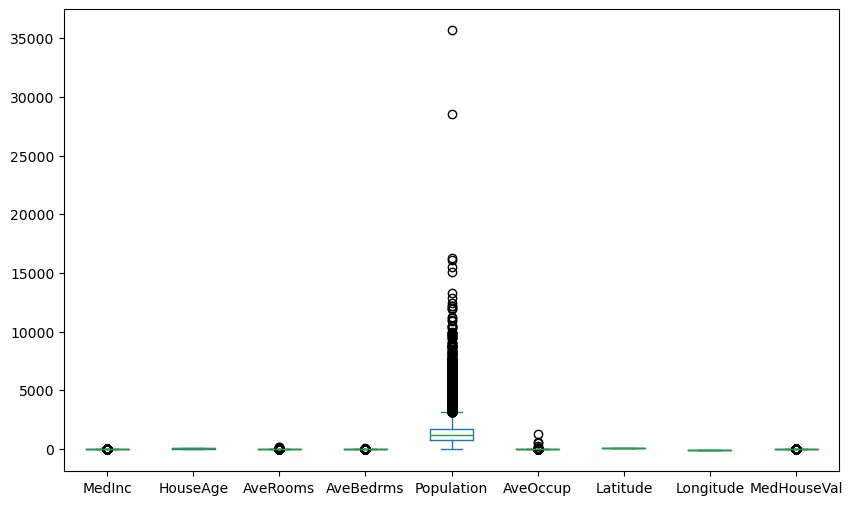

In [18]:
df.plot(kind='box', figsize=(10,6))
plt.show()

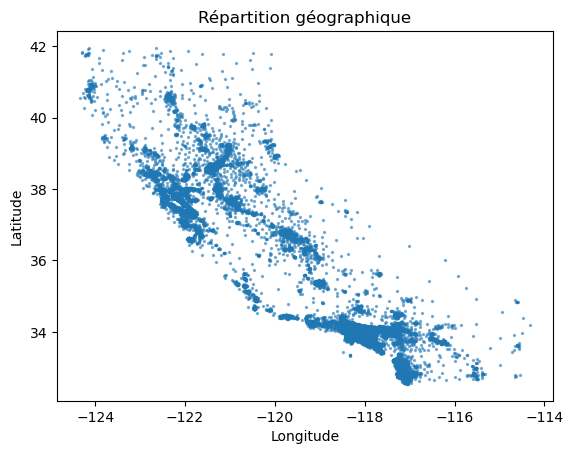

In [32]:
plt.scatter(df["Longitude"], df["Latitude"], s=2 , alpha=0.5)
plt.title("Répartition géographique")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:

corr = df.corr()
print(corr)


               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

In [37]:

top3 = corr['MedHouseVal'].drop('MedHouseVal').abs().nlargest(3)
print(top3)


MedInc      0.688075
AveRooms    0.151948
Latitude    0.144160
Name: MedHouseVal, dtype: float64


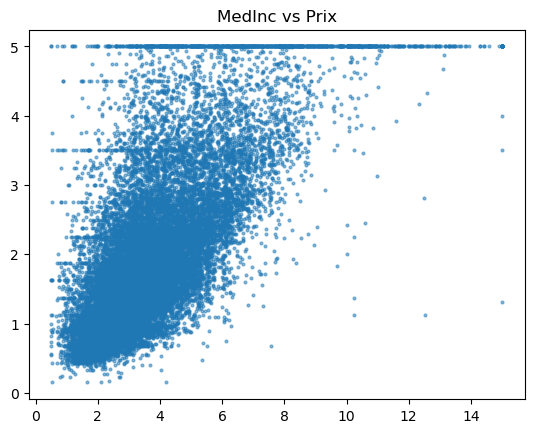

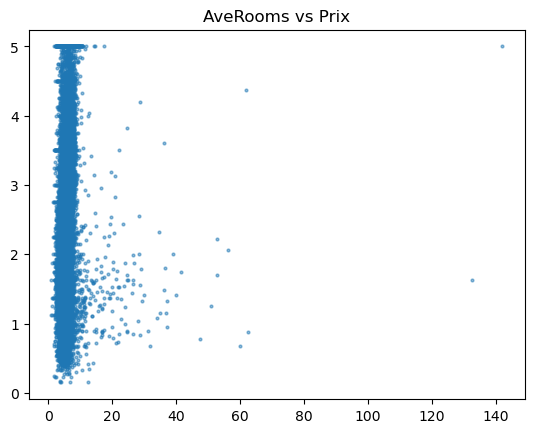

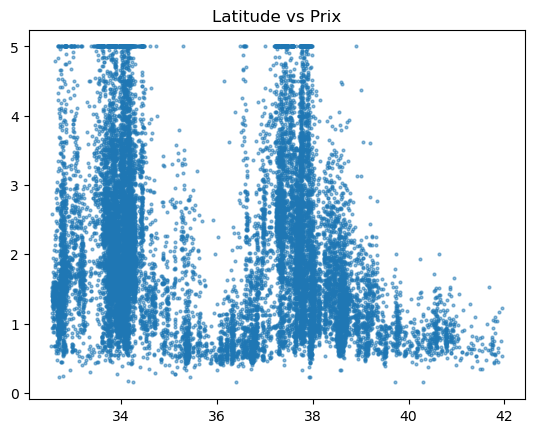

In [ ]:

for col in top3.index:
    plt.scatter(df[col], df["MedHouseVal"],s=4 , alpha=0.5)
    plt.title(f"{col} vs Prix")
    plt.show()

In [ ]:
print(df.skew())


MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64


In [47]:

for col in df.columns:
    if abs(df[col].skew()) < 0.5:
        print(col, "≈ distribution normale")
    else:
        print(col, "distribution asymétrique")

MedInc distribution asymétrique
HouseAge ≈ distribution normale
AveRooms distribution asymétrique
AveBedrms distribution asymétrique
Population distribution asymétrique
AveOccup distribution asymétrique
Latitude ≈ distribution normale
Longitude ≈ distribution normale
MedHouseVal distribution asymétrique


In [50]:

df['Region'] = pd.cut(df['Latitude'], bins=10)
region_prix = df.groupby('Region')['MedHouseVal'].mean().sort_values(ascending=False)
print(region_prix)



Region
(37.245, 38.186]    2.424769
(33.481, 34.422]    2.287872
(32.531, 33.481]    1.933825
(34.422, 35.363]    1.713885
(36.304, 37.245]    1.570614
(38.186, 39.127]    1.516993
(39.127, 40.068]    1.048045
(35.363, 36.304]    0.913435
(40.068, 41.009]    0.872176
(41.009, 41.95]     0.732103
Name: MedHouseVal, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_18412\2448165931.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_prix = df.groupby('Region')['MedHouseVal'].mean().sort_values(ascending=False)


In [53]:

mean_price = df['MedHouseVal'].mean()
df_cher = df[df['MedHouseVal'] > mean_price]
print("la moyenne:" ,mean_price)
print("Maisons au-dessus de la moyenne  :" ,len(df_cher) )


la moyenne: 2.0685581690891475
Maisons au-dessus de la moyenne  : 8385


In [54]:

print("\nZones les plus chères  :", region_prix.index[0])
print("Zones les moins chères :", region_prix.index[-1])


Zones les plus chères  : (37.245, 38.186]
Zones les moins chères : (41.009, 41.95]


In [ ]:
numeric_df = df.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | 
            (numeric_df > (Q3 + 1.5 * IQR)))

print(outliers.sum())

MedInc          681
HouseAge          0
AveRooms        511
AveBedrms      1424
Population     1196
AveOccup        711
Latitude          0
Longitude         0
MedHouseVal    1071
dtype: int64


In [60]:
from scipy.stats import zscore


z_scores = numeric_df.apply(zscore)

print((abs(z_scores) > 3).sum())

MedInc         345
HouseAge         0
AveRooms       133
AveBedrms      145
Population     342
AveOccup         8
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64


In [63]:
df_feat = df.copy()

df_feat['PrixParPiece']  = df_feat['MedHouseVal'] / (df_feat['AveRooms'] )
df_feat.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region,PrixParPiece
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,"(37.245, 38.186]",0.648041
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,"(37.245, 38.186]",0.574691
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,"(37.245, 38.186]",0.424824
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,"(37.245, 38.186]",0.586693
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,"(37.245, 38.186]",0.544744


In [65]:
df_feat["Income_cat"] = pd.cut(df_feat["MedInc"],
                         bins=3,
                         labels=["Faible", "Moyen", "Élevé"])
df_feat.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region,PrixParPiece,Income_cat
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,"(37.245, 38.186]",0.648041,Moyen
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,"(37.245, 38.186]",0.574691,Moyen
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,"(37.245, 38.186]",0.424824,Moyen
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,"(37.245, 38.186]",0.586693,Moyen
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,"(37.245, 38.186]",0.544744,Faible


In [67]:
df_feat["Age_cat"] = pd.cut(df_feat["HouseAge"],
                       bins=[0, 20, 40, 60],
                       labels=["Jeune", "Moyen", "Ancien"])
df_feat.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region,PrixParPiece,Income_cat,Age_cat
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,"(37.245, 38.186]",0.648041,Moyen,Ancien
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,"(37.245, 38.186]",0.574691,Moyen,Moyen
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,"(37.245, 38.186]",0.424824,Moyen,Ancien
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,"(37.245, 38.186]",0.586693,Moyen,Ancien
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,"(37.245, 38.186]",0.544744,Faible,Ancien


In [68]:
df_feat["Price_cat"] = pd.qcut(df_feat["MedHouseVal"],
                         q=4,
                         labels=["Bas", "Moyen", "Élevé", "Très élevé"])
df_feat.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region,PrixParPiece,Income_cat,Age_cat,Price_cat
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,"(37.245, 38.186]",0.648041,Moyen,Ancien,Très élevé
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,"(37.245, 38.186]",0.574691,Moyen,Moyen,Très élevé
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,"(37.245, 38.186]",0.424824,Moyen,Ancien,Très élevé
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,"(37.245, 38.186]",0.586693,Moyen,Ancien,Très élevé
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,"(37.245, 38.186]",0.544744,Faible,Ancien,Très élevé


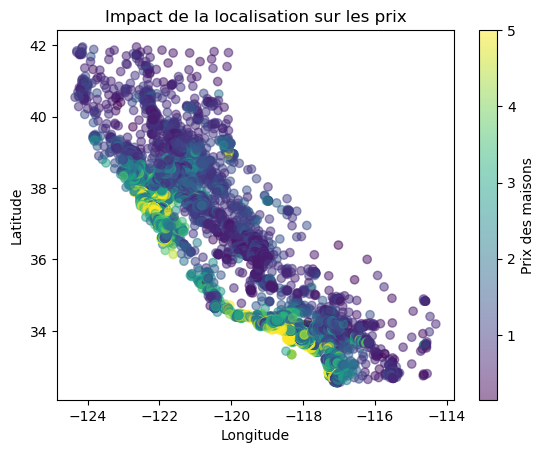

In [69]:
import matplotlib.pyplot as plt

plt.scatter(df["Longitude"], df["Latitude"],
            c=df["MedHouseVal"], cmap="viridis", alpha=0.5)

plt.colorbar(label="Prix des maisons")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Impact de la localisation sur les prix")
plt.show()

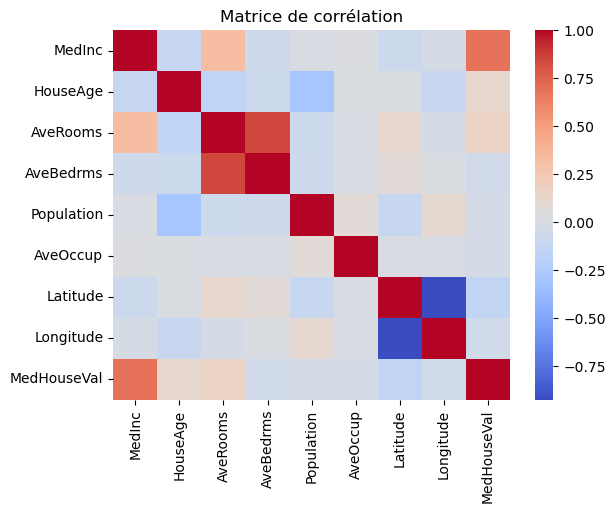

In [71]:


import seaborn as sns
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

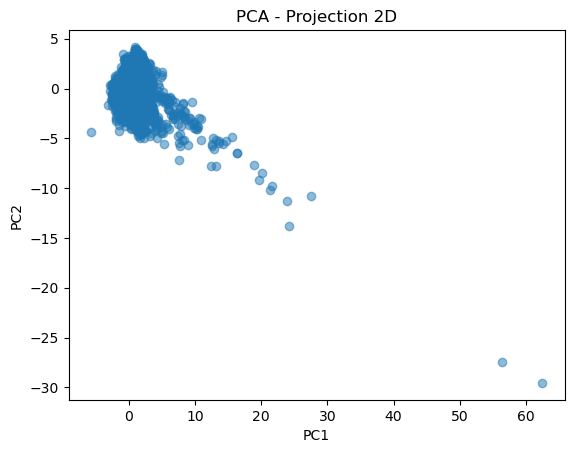

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sélection des variables numériques
X = df.select_dtypes(include='number')

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisation
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA - Projection 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()